# TALLER 2 ANALISIS NUMÉRICO

## EJERCICIOS DE APLICACIÓN

**Docente:** Leidy Yoana Medina Torres

---

### Integrantes del equipo de trabajo

- *DANIEL MORALES*
- *JUAN MANUEL GOMEZ*

---

In [2]:
# Imports

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import sel as s
import modelos as ml
import Ceros as c

# Ejercicio 1 — Crecimiento alométrico de la Platija

El crecimiento alométrico es el estudio del tamaño relativo de diferentes partes de un organismo como consecuencia del crecimiento. Se realizó un experimento relacionando el peso de la platija (especie de pez) $w(t)$ con respecto a su longitud $L(t)$.

| Longitud (cm) | Peso (g) | Longitud (cm) | Peso (g) |
|:---:|:---:|:---:|:---:|
| 23.5 | 124 | 37.5 | 455 |
| 24.5 | 146 | 38.5 | 500 |
| 25.5 | 155 | 39.5 | 538 |
| 26.5 | 174 | 40.5 | 574 |
| 27.5 | 190 | 41.5 | 623 |
| 28.5 | 213 | 42.5 | 674 |
| 29.5 | 236 | 43.5 | 724 |
| 30.5 | 259 | 44.5 | 808 |
| 31.5 | 284 | 45.5 | 812 |
| 32.5 | 308 | 46.5 | 909 |
| 33.5 | 332 | 47.5 | 1039 |
| 34.5 | 363 | 48.5 | 1124 |
| 35.5 | 391 | 49.5 | 1163 |
| 36.5 | 419 |  |  |

**a)** Hacer un gráfico de los datos longitud versus peso de la Platija.

**b)** Construir un polinomio que pase por cada uno del conjunto de datos y aproxime el peso de una platija americana cuya longitud máxima registrada es de 60 cm. Concluya si el modelo construido es coherente, si representa la tendencia de la información proporcionada.

**c)** Construya un modelo de ajuste que represente la tendencia de los datos proporcionados y permita aproximar el peso de una platija americana cuya longitud máxima registrada es de 60 cm. Concluya si el modelo es coherente, pertinente y si su construcción es adecuada con base únicamente en los datos suministrados.

**d)** Hacer las gráficas de cada ítem de manera separada.

In [3]:
L_data = np.array([23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
                   33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5,
                   43.5, 44.5, 45.5, 46.5, 47.5, 48.5, 49.5])

w_data = np.array([124, 146, 155, 174, 190, 213, 236, 259, 284, 308,
                   332, 363, 391, 419, 455, 500, 538, 574, 623, 674,
                   724, 808, 812, 909, 1039, 1124, 1163])

### a) Gráfico de los datos longitud vs peso


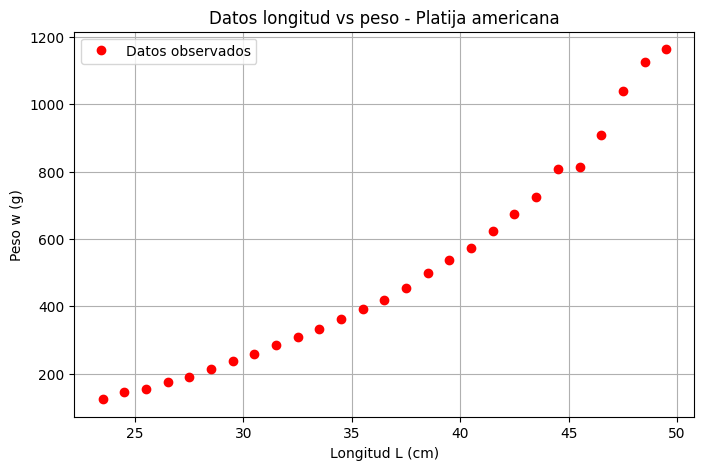

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.title('Datos longitud vs peso - Platija americana')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

### b) Polinomio interpolante que pasa por todos los puntos

In [ ]:
x = sp.symbols('x')

P_lagrange = ml.lagrange(L_data, w_data)
P_func = sp.lambdify(x, P_lagrange)

w_60_poli = float(P_func(60))
print(f"Aproximacion del peso para L = 60 cm: w(60) = {w_60_poli}")


# justificacion: el polinomio de grado 26 pasa exactamente por los puntos del
# intervalo [23.5, 49.5] cm pero al extrapolar a L = 60 cm produce un valor sin
# sentido fisico, por lo que el modelo no es coherente para predecir el peso fuera 
# del rango muestreado

Aproximacion del peso para L = 60 cm: w(60) = -4215794534925375.0


### c) Modelo de ajuste por mínimos cuadrados

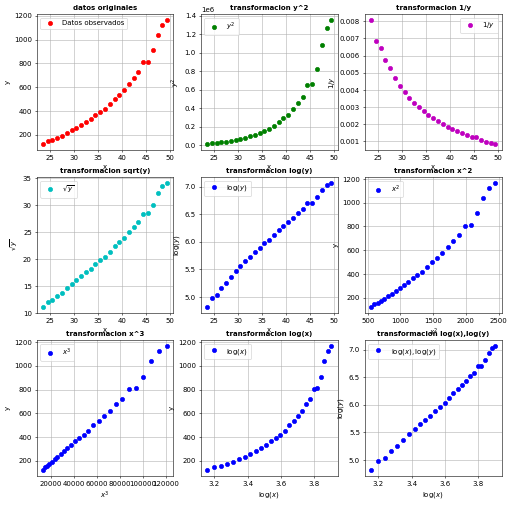

In [7]:
# Visualizacion de las escalas para escoger la transformacion que mas linealiza
ml.escalas(L_data, w_data)

In [8]:
# Coeficientes de determinacion para los modelos candidatos
R_lineal  = ml.coeficiente_determinacion(L_data, w_data)
R_x3      = ml.coeficiente_determinacion(L_data**3, w_data)
R_loglog  = ml.coeficiente_determinacion(np.log(L_data), np.log(w_data))

print(f"R^2 (L, w)              : {R_lineal}")
print(f"R^2 (L^3, w)            : {R_x3}")
print(f"R^2 (log(L), log(w))    : {R_loglog}")

R^2 (L, w)              : 0.9362218067143112
R^2 (L^3, w)            : 0.9918775506182635
R^2 (log(L), log(w))    : 0.9961836639396179


### d) Gráficas de cada ítem por separado

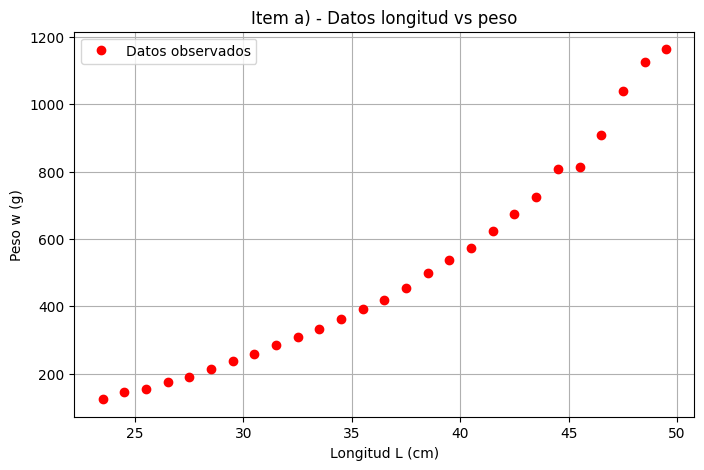

In [11]:
# Grafica del item a)
plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.title('Item a) - Datos longitud vs peso')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

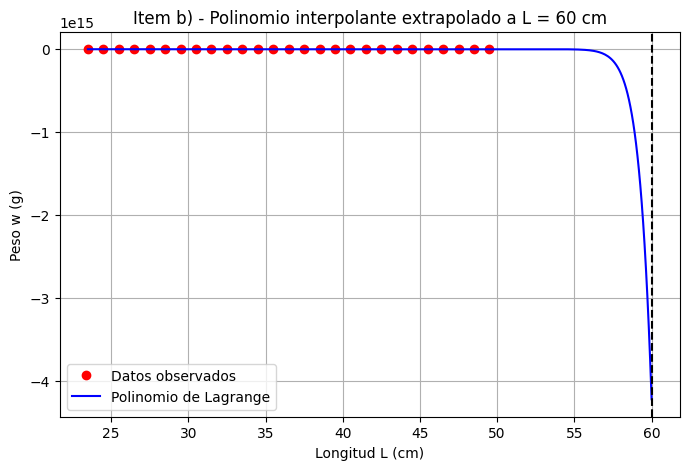

In [12]:
# Grafica del item b)
L_plot_b = np.linspace(L_data.min(), 60, 400)
y_plot_b = np.array([float(P_func(Li)) for Li in L_plot_b])

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_b, y_plot_b, 'b-', label='Polinomio de Lagrange')
plt.axvline(60, color='k', linestyle='--')
plt.title('Item b) - Polinomio interpolante extrapolado a L = 60 cm')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

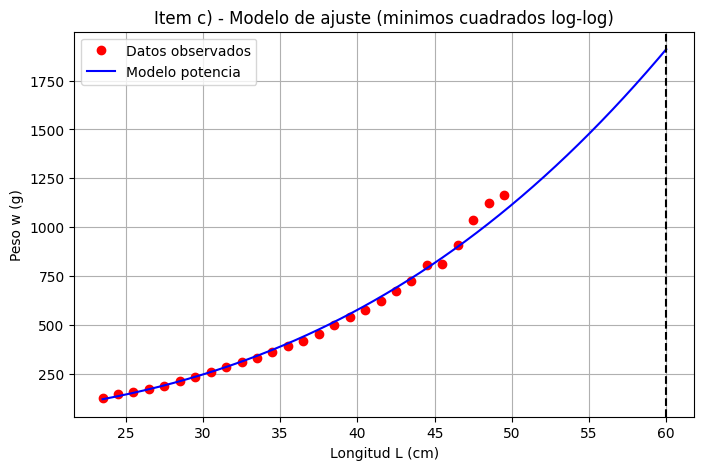

In [13]:
# Grafica del item c)
L_plot_c = np.linspace(L_data.min(), 60, 200)

plt.figure(figsize=(8, 5))
plt.plot(L_data, w_data, 'or', label='Datos observados')
plt.plot(L_plot_c, w_modelo(L_plot_c), 'b-', label='Modelo potencia')
plt.axvline(60, color='k', linestyle='--')
plt.title('Item c) - Modelo de ajuste (minimos cuadrados log-log)')
plt.xlabel('Longitud L (cm)')
plt.ylabel('Peso w (g)')
plt.grid(True)
plt.legend()
plt.show()

# Ejercicio 2 — Salto vertical de una bailarina de ballet

Un salto vertical realizado por una bailarina de ballet está descrito por la ecuación diferencial

$$m\, v' = -m\, g$$

Aquí $m$ es la masa de la bailarina de ballet, $g = 32.2\ \text{pies}/\text{s}^2$ es la constante gravitacional y $v' = \dfrac{dv}{dt}$, $v = \dfrac{dy}{dt}$, donde $y$ es la distancia vertical medida desde el piso hasta el centro de gravedad de la bailarina.

Se considera que en $t = 0$ la bailarina despega con velocidad inicial

$$v_0 = \frac{g\, T}{2},$$

siendo $T$ el tiempo total de vuelo.

**a)** Resolver numéricamente la ecuación diferencial utilizando el método de Euler y el método de Runge-Kutta de cuarto orden (RK4) para $T = 1/3$ segundos.

**b)** Comparar la altura máxima obtenida numéricamente con el valor exacto

$$H = \tfrac{1}{8}\, g\, T^{2} \approx 5.4\ \text{pulgadas}.$$

**c)** Analizar el error cometido por cada método para diferentes tamaños de paso $\Delta t$.

**d)** Realizar la gráfica del tiempo versus la altura, y el tiempo versus la velocidad e interprete.

# Ejercicio 3 — Crecimiento alométrico del cangrejo violinista

El cangrejo violinista es un pequeño crustáceo, famoso porque los machos poseen una pinza desproporcionadamente grande, usada para cortejo y defensa, que recuerda a un violín.

El crecimiento alométrico es el estudio de los tamaños relativos de las diferentes partes de un organismo como consecuencia del crecimiento. Uno de los modelos más simples de alometría es aquel en el que se supone que las razones de crecimiento relativo de los dos componentes $y(t)$ y $x(t)$ satisfacen:

$$\frac{dy}{dx} = a\, \frac{y}{x}$$

donde $a$ es una constante. La tabla muestra los resultados de un experimento en el cual se obtuvieron los pesos relativos del cuerpo y la tenaza del cangrejo violinista. El peso del cuerpo es el peso total del cangrejo restando el peso de la tenaza. Aunque es posible describir este conjunto de datos en una simple ecuación alométrica, resulta un modelo mejor si se conjuntan dos ecuaciones alométricas.

| Peso del cuerpo (mg) | Peso de la tenaza (mg) | Peso del cuerpo (mg) | Peso de la tenaza (mg) |
|:---:|:---:|:---:|:---:|
| 57.6 | 5.3 | 680.6 | 271.6 |
| 80.3 | 9.0 | 743.3 | 319.2 |
| 109.2 | 13.7 | 872.4 | 417.6 |
| 156.1 | 25.1 | 983.1 | 460.8 |
| 199.7 | 38.3 | 1079.9 | 537.0 |
| 283.3 | 52.5 | 1165.5 | 593.8 |
| 270.0 | 59.0 | 1211.7 | 616.8 |
| 300.2 | 78.1 | 1291.3 | 670.0 |
| 355.2 | 104.5 | 1363.2 | 699.3 |
| 420.1 | 135.0 | 1449.1 | 777.8 |
| 470.1 | 164.9 | 1807.9 | 1009.1 |
| 535.7 | 195.6 | 2235.0 | 1380.0 |
| 617.9 | 243.0 |  |  |

**a)** Construya un polinomio que pase por todos los puntos. Se cree que la iniciación de la madurez sexual de un cangrejo violinista se presenta cuando su peso total excede alrededor de 1.1 g. ¿Es consistente con su modelo? Haga una gráfica de los datos versus el modelo construido.

**b)** Construya un modelo no lineal en dos fases, uno para el grupo joven y otro para el grupo maduro. Haga una gráfica del modelo versus los datos.

**c)** ¿Qué significa que el crecimiento sea **alométrico**? Diferéncielo del crecimiento **isométrico**.

**d)** Compare los exponentes alométricos obtenidos para la fase joven y la fase madura. ¿Qué diferencia observa y qué significado biológico podría tener?

**e)** Según su modelo de dos fases, ¿en cuál etapa crece proporcionalmente más la tenaza con respecto al cuerpo? Justifique.

**f)** Utilizando el modelo de dos fases, estime el peso de la tenaza para un cangrejo cuyo cuerpo pesa 500 mg y para otro cuyo cuerpo pesa 2000 mg. ¿En qué fase se encuentra cada uno?

**g)** Si se desea predecir el peso de la tenaza para un cangrejo con peso corporal de 3000 mg, ¿cuál de los dos modelos (polinomio exacto o dos fases) es más confiable? ¿Por qué?

# Ejercicio 4 — Modelo de Lotka-Volterra (compradores y vendedores)

Del modelo de Lotka-Volterra vamos a representar el comportamiento de dos poblaciones, en este caso los **vendedores** y los **compradores**. Supongamos que $x(t)$ representa el número de compradores en un determinado tiempo $t$ y sea $v(t)$ la representación de los vendedores en un determinado tiempo $t$. El modelo de competencia es:

$$
\begin{aligned}
\frac{dx}{dt} &= x(t)\,\bigl(a - b\, x(t) - m\, v(t)\bigr), \qquad x(0) = 75 \\[4pt]
\frac{dv}{dt} &= v(t)\,\bigl(c - d\, v(t) - n\, x(t)\bigr), \qquad v(0) = 20
\end{aligned}
$$

donde:

- $m$ es la medida del grado en que los vendedores interfieren con los compradores,
- $n$ es la medida del grado en que los compradores interactúan con los vendedores,
- $b$ es la interacción entre compradores,
- $d$ es la interacción entre vendedores.

*(Si cree que es necesario ajuste los valores, pero justifique su cambio.)*

**a)** Determine la solución para las siguientes constantes:

$$a = 0.3,\ b = 0.01,\ m = 0.06,\ c = 0.03,\ d = 0.009,\ n = 0.0055.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete. *(Ambos coexisten en un punto fijo estable.)*

**b)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.2,\ m = 0.06,\ c = 0.06,\ d = 0.01,\ n = 0.015.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

**c)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.02,\ m = 0.06,\ c = 0.26,\ d = 0.9,\ n = 4.2.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.

**d)** Determine la solución para las siguientes constantes:

$$a = 0.26,\ b = 0.021,\ m = 0.06,\ c = 0.06,\ d = 0.01,\ n = 0.01.$$

Realice los gráficos de $x(t)$ vs tiempo, $v(t)$ vs tiempo, $x(t)$ vs $v(t)$ e interprete.